# CNN explainability walkthrough

A guided tour of the methods used in this repository, on one portrait and on the saved LFW
results. The numbers in the README come from `make run` (the pipeline), not from this notebook;
the notebook is the place to poke at the methods interactively.

1. What filters respond to (activation maximisation)
2. What one prediction relies on (Grad-CAM and occlusion)
3. Why the ImageNet label of a masked photo says nothing about re-identification
4. The re-identification experiment on LFW (results loaded from `results/`)

In [1]:
# On Google Colab: fetch the repository and install the package (skipped when run locally).
import os
import sys

if "google.colab" in sys.modules and not os.path.exists("cnn-explainability-workshop"):
    !git clone --depth 1 https://github.com/Pchambet/cnn-explainability-workshop
    %pip install -q -e cnn-explainability-workshop
if os.path.exists("cnn-explainability-workshop"):
    os.chdir("cnn-explainability-workshop")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import csv

import matplotlib.pyplot as plt
import numpy as np

from cnn_explainability import explain, masks, vgg
from cnn_explainability.lfw import load_image

vgg.limit_threads(3)
model = vgg.load_vgg16(include_top=True)
notop = vgg.load_vgg16(include_top=False)
portrait = vgg.resize(load_image("assets/portrait.jpg", crop=None))
print(f"VGG16: {model.count_params():,} parameters")

VGG16: 138,357,544 parameters


## 1. What a filter responds to

Gradient ascent in pixel space: start from noise and change the image to increase one
filter's mean activation. Early filters prefer colours and oriented edges; deep filters prefer
textures and object parts. This shows what a filter *can* detect, not what it uses on a given
image.

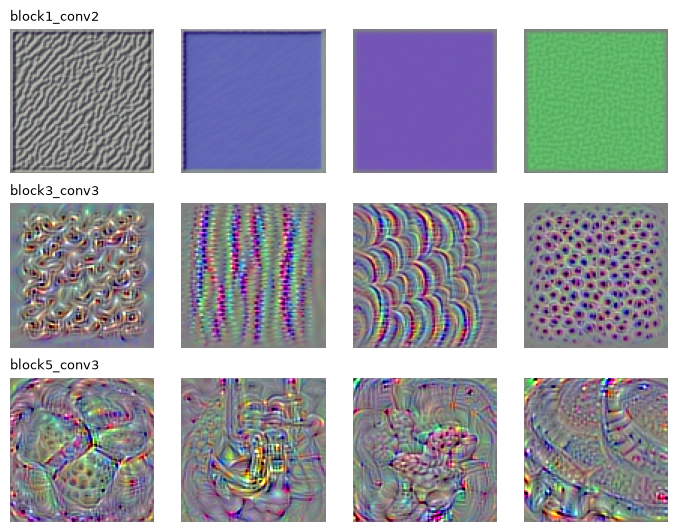

In [3]:
layers = ["block1_conv2", "block3_conv3", "block5_conv3"]
fig, axes = plt.subplots(len(layers), 4, figsize=(7, 5.4))
for row, layer in enumerate(layers):
    images = explain.maximise_activation(
        notop, layer, [0, 1, 2, 3], size=96, steps=20, preprocess=vgg.preprocess_unit
    )
    for col, img in enumerate(images):
        axes[row, col].imshow(img)
        axes[row, col].set_axis_off()
    axes[row, 0].set_title(layer, loc="left", fontsize=9)
plt.tight_layout()

## 2. What one prediction relies on

VGG16 was trained on ImageNet's 1,000 object classes, which contain no "person" or identity
class. On a portrait it predicts an object class. Grad-CAM weights the feature maps of a layer
by the gradient of that class's pre-softmax score; occlusion hides a grey patch at every position and
records the drop in probability.

               loupe  p = 0.207
          binoculars  p = 0.172
         stethoscope  p = 0.117
            lens_cap  p = 0.053
         rain_barrel  p = 0.023


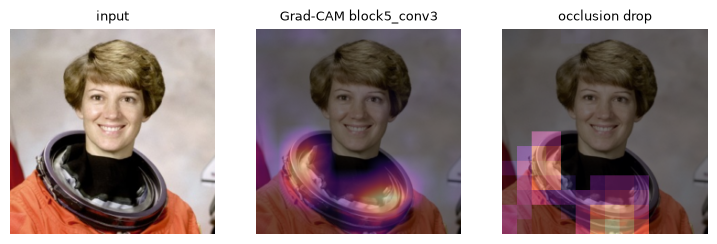

In [4]:
x = vgg.preprocess(portrait[None])
probs = model(x, training=False).numpy()[0]
top = np.argsort(probs)[::-1][:5]
for label, i in zip(vgg.decode_top1(np.eye(1000)[top]), top, strict=True):
    print(f"{label[0]:>20s}  p = {probs[i]:.3f}")
target = int(top[0])

cam = explain.upsample(explain.grad_cam(model, x, "block5_conv3", target), (224, 224))


def class_prob(batch):
    return model(vgg.preprocess(batch), training=False).numpy()[:, target]


occ, base = explain.occlusion_map(portrait, class_prob, patch=32, stride=16)
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, (title, heat) in zip(
    axes, [("input", None), ("Grad-CAM block5_conv3", cam), ("occlusion drop", occ)], strict=True
):
    ax.imshow(portrait)
    if heat is not None:
        ax.imshow(np.clip(heat, 0, None), cmap="magma", alpha=0.55)
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()

## 3. The wrong measurement

The first version of this workshop masked the eyes of the portrait and reported how the
probability of its top ImageNet class changed. That number describes an object
classifier; it cannot say whether the *person* is still recognisable. The cell below
reproduces it so the difference is visible.

In [5]:
for condition, label in masks.CONDITIONS.items():
    masked = masks.apply(portrait, condition, masks.PORTRAIT_LAYOUT)
    p = model(vgg.preprocess(masked[None]), training=False).numpy()
    ((top1, score),) = vgg.decode_top1(p)
    print(f"{label:>18s}: top-1 {top1:<12s} p = {score:.3f}")

           No mask: top-1 loupe        p = 0.207


           Eye bar: top-1 loupe        p = 0.452


   Eyes + nose bar: top-1 loupe        p = 0.621


    Mild face blur: top-1 loupe        p = 0.559
  Strong face blur: top-1 loupe        p = 0.647


  Face blacked out: top-1 loupe        p = 0.649


## 4. The right measurement: one-shot re-identification on LFW

The pipeline (`make run`) enrols one clean photo of each of 62 LFW identities and asks which
enrolled person each *masked* photo is closest to. The table is read from
`results/lfw_summary.csv`: mean rank-1 accuracy over 20 enrolment draws.

In [6]:
with open("results/lfw_summary.csv") as handle:
    rows = list(csv.DictReader(handle))
reps = list(dict.fromkeys(r["representation"] for r in rows))
print(f"{'condition':>15s}" + "".join(f"{rep:>12s}" for rep in reps))
for condition in masks.CONDITIONS:
    cells = [
        next(
            r
            for r in rows
            if r["representation"] == rep
            and r["condition"] == condition
            and r["gallery"] == "clean"
        )
        for rep in reps
    ]
    print(f"{condition:>15s}" + "".join(f"{float(c['rank1_mean']):>12.1%}" for c in cells))

      condition  vgg16_flat   vgg16_gap  eigenfaces      pixels
           none       17.5%       16.7%       11.6%        9.5%
        eye_bar       13.9%       12.7%        6.3%        8.6%
  eyes_nose_bar       13.1%       10.7%        4.7%        6.4%
      blur_mild       13.8%        9.5%       10.2%        8.9%
    blur_strong       12.8%        6.6%        6.9%        8.1%
       face_box       10.8%        5.4%        5.1%        4.0%


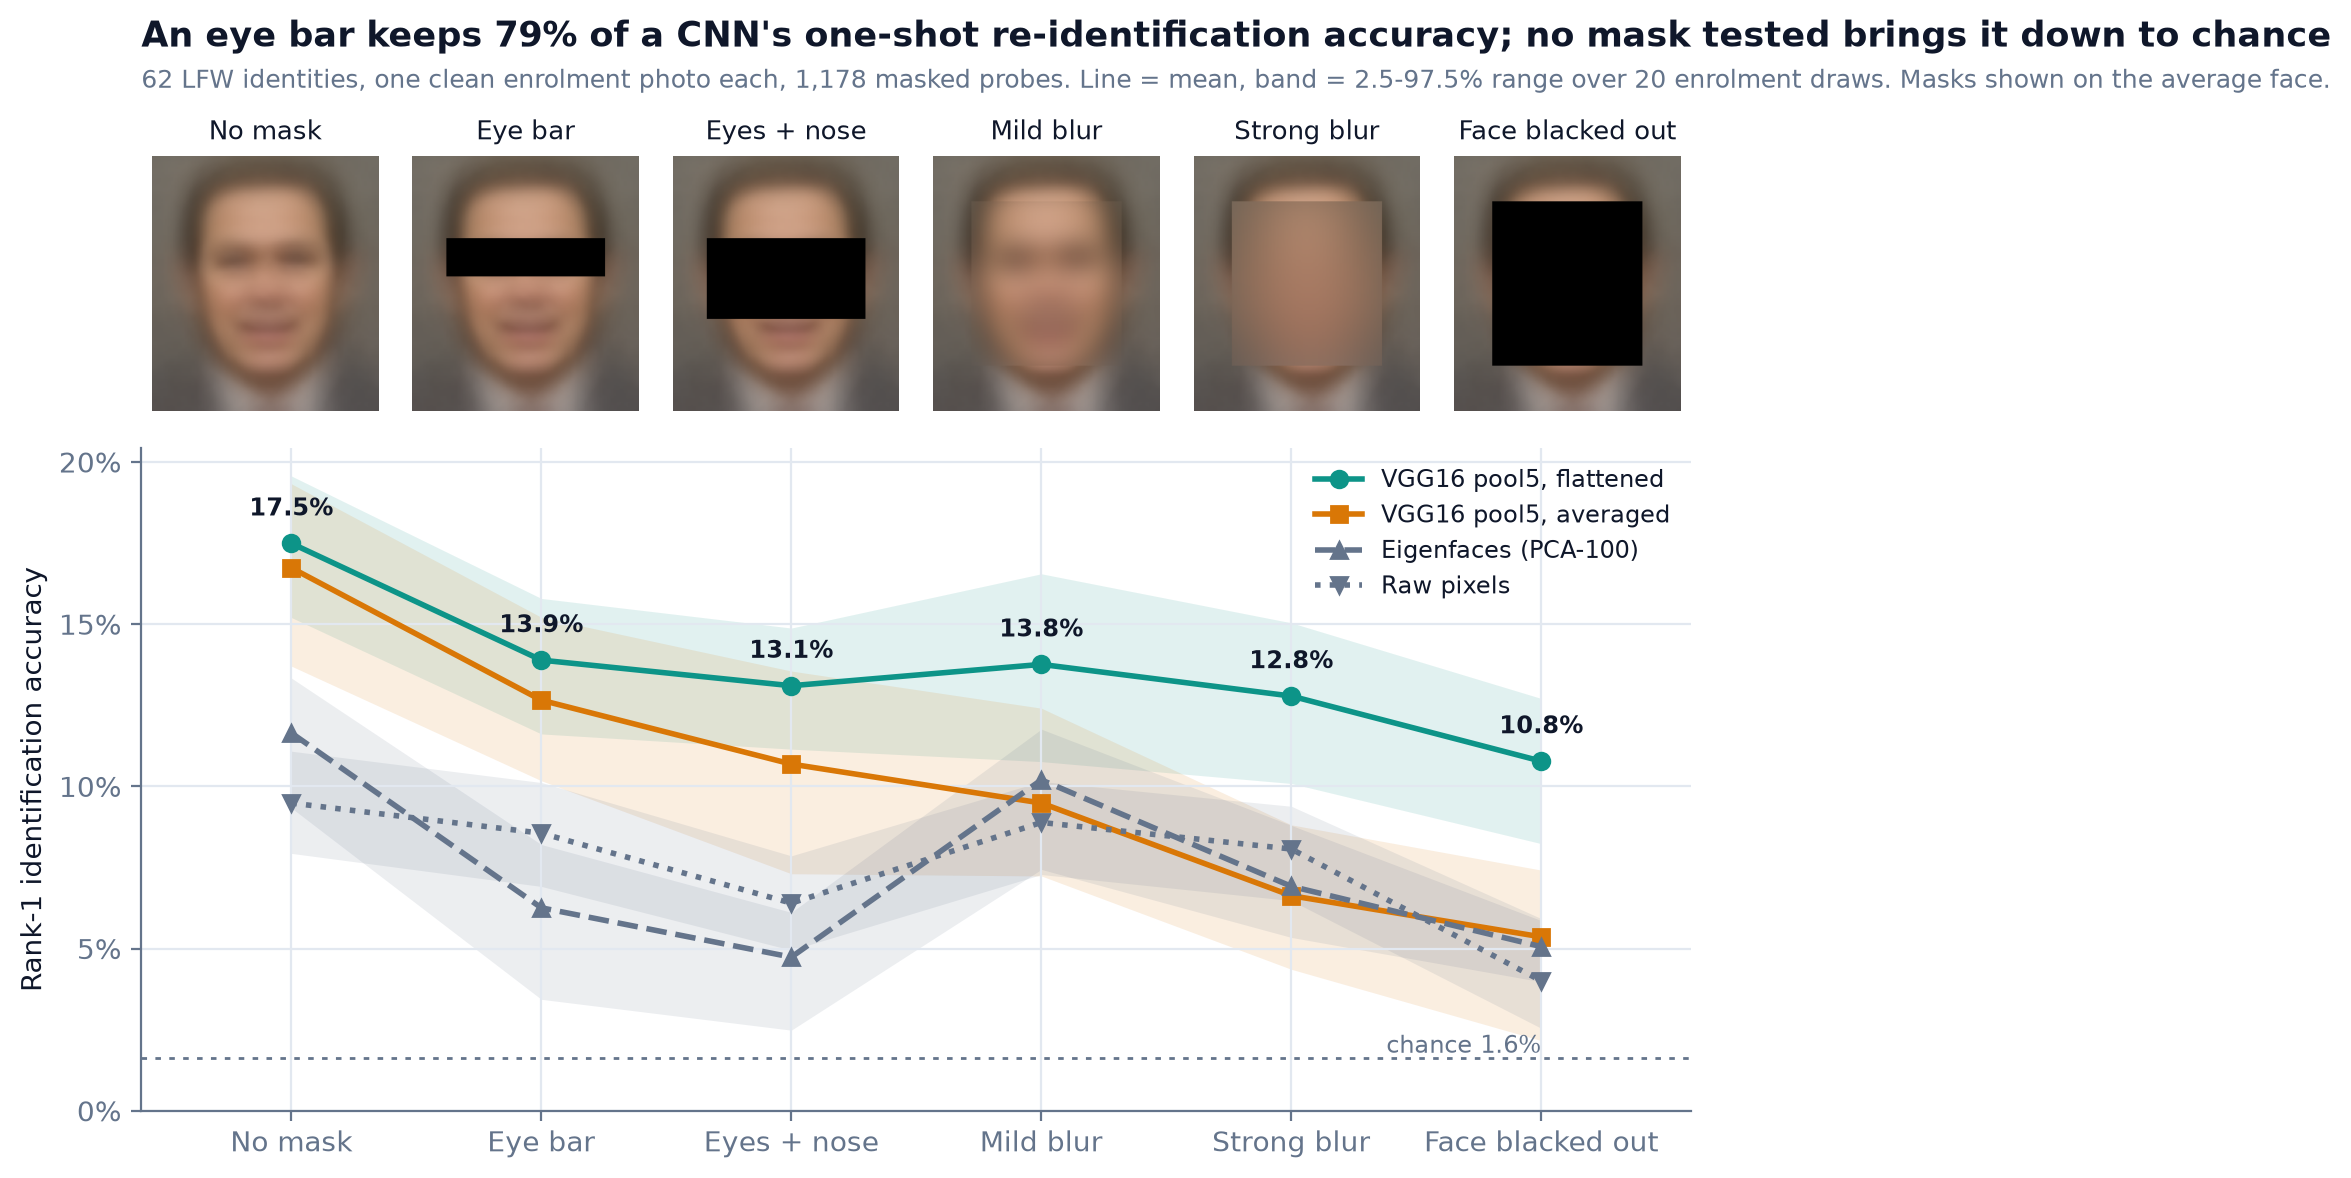

In [7]:
from IPython.display import Image

Image("docs/figures/hero.png", width=760)